In [1]:
import sys

sys.path.append("~/UnReflectAnything/")
from utilities import rgb, panelize
import torch
from dataset.rgbp import HOUSECAT6D_Dataset

%load_ext autoreload
%autoreload 2    


ModuleNotFoundError: No module named 'utilities'

In [1]:
import torch
torch.cuda.is_available()

True

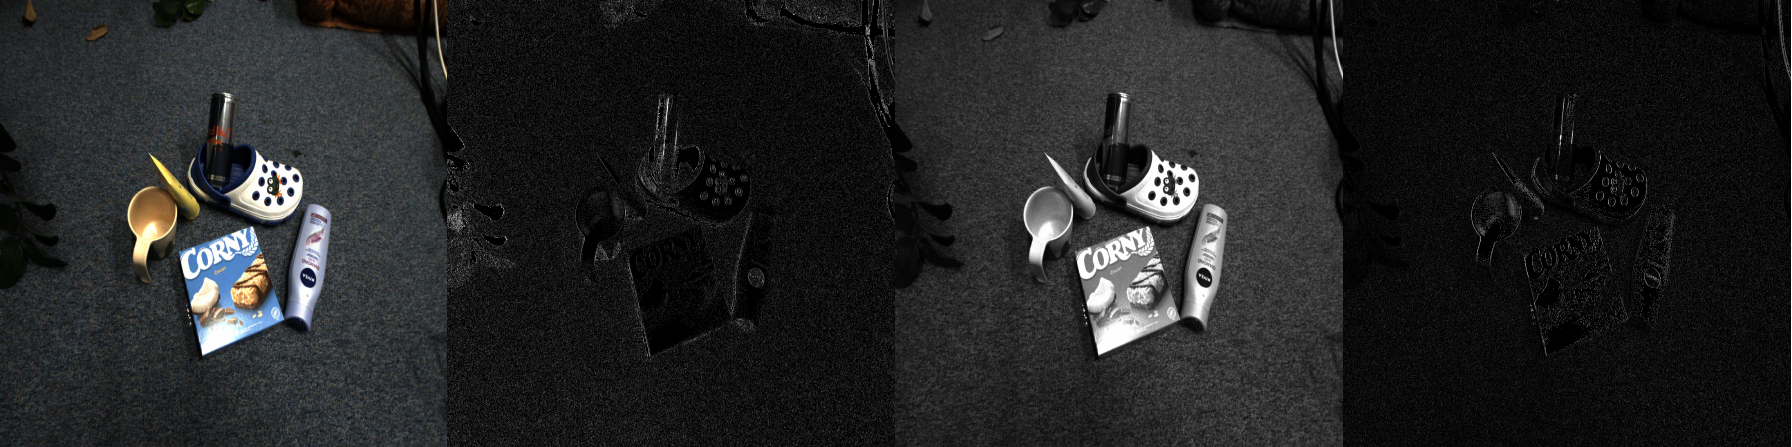

In [2]:
dataset = HOUSECAT6D_Dataset(
    root_dir="/datasets/HouseCat6D/",
    # scene_names=["scene01"],
    target_size=[448, 448],
    resize_mode="resize",
    rho_s=0.6,
    eps=1e-8,
)

# Create dataloader
dataloader = torch.utils.data.DataLoader(dataset, batch_size=1, shuffle=True)
idataloade = iter(dataloader)

# Test loading a batch
for b, batch in enumerate(dataloader):
    break
rgb(
    panelize(
        rgb(
            batch["rgb"][0],
            as_tensor=True,
            resize=(448, 448),
            colormap="gray",
        ),
        rgb(
            batch["DoP"][0],
            as_tensor=True,
            resize=(448, 448),
            colormap="gray",
        ),
        rgb(
            batch["S0"][0],
            as_tensor=True,
            resize=(448, 448),
            colormap="gray",
        ),
        rgb(
            batch["f_spec"][0],
            as_tensor=True,
            resize=(448, 448),
            colormap="gray",
        ),
    )
)

In [3]:
from models import DINOv3

dino = DINOv3(config={"return_as_feature_maps": True})
dino.eval()
dino.to("cuda")

I0_dino = dino.preprocess_image(batch["I0"].cuda())
I45_dino = dino.preprocess_image(batch["I45"].cuda())
I90_dino = dino.preprocess_image(batch["I90"].cuda())
I135_dino = dino.preprocess_image(batch["I135"].cuda())

I0_dino = dino(I0_dino)
I45_dino = dino(I45_dino)
I90_dino = dino(I90_dino)
I135_dino = dino(I135_dino)




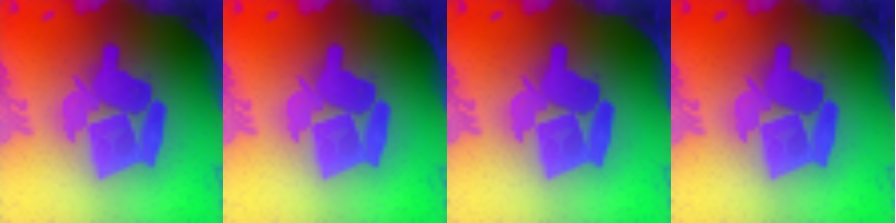

In [4]:
rgb(
    panelize(
        rgb(
            I0_dino["last_hidden_state"][0],
            as_tensor=True,
            resize=(224,224)
        ),
        rgb(
            I45_dino["last_hidden_state"][0],
            as_tensor=True,
            resize=(224,224)
        ),
        rgb(
            I90_dino["last_hidden_state"][0],
            as_tensor=True,
            resize=(224,224)
        ),
        rgb(
            I135_dino["last_hidden_state"][0],
            as_tensor=True,
            resize=(224,224)
        ),
    )
)

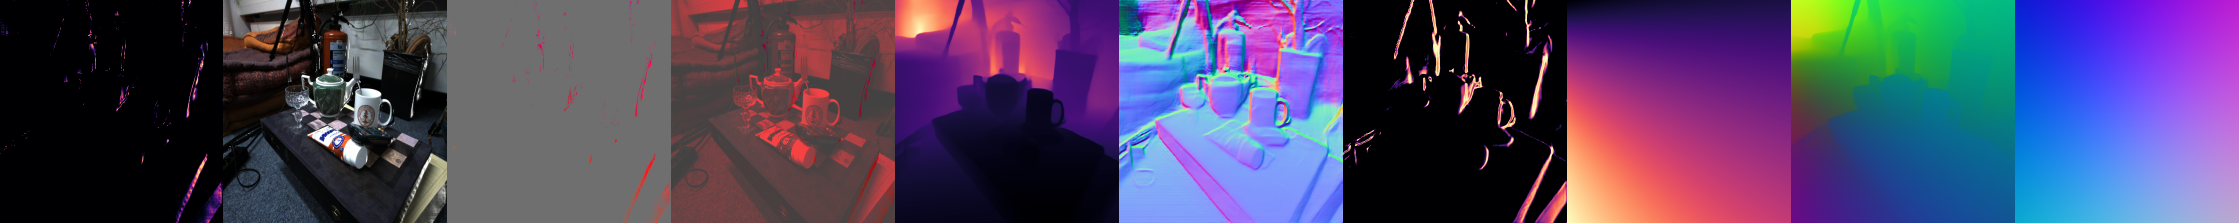

In [23]:
dataset = HOUSECAT6D_Dataset(
    root_dir="/datasets/HouseCat6D/",
    # scene_names=["scene01"],
    target_size=[448, 448],
    resize_mode="resize",
    rho_s=0.6,
    eps=1e-8,
)

# Create dataloader
dataloader = torch.utils.data.DataLoader(dataset, batch_size=1, shuffle=True)
idataloade = iter(dataloader)

# Test loading a batch
for b, batch in enumerate(dataloader):
    break
image = batch["rgb"].cuda()
pol = torch.cat([batch["S0"], batch["S1"], batch["S2"]], dim=1).cuda()
intrinsic = batch["intrinsics"].cuda()
intrinsic_res = intrinsic.clone()
intrinsic_res[0,0,0] = intrinsic[0,0,0] * 448/1140
intrinsic_res[0,1,1] = intrinsic[0,1,1] * 448/892
intrinsic_res[0,0,2] = intrinsic[0,0,2] * 448/1140
intrinsic_res[0,1,2] = intrinsic[0,1,2] * 448/892
result = ph(image, pol, intrinsic_res)
# ph.print_timing_stats()
rgb(
    panelize(
        *[
            rgb(x[0], as_tensor=True, resize=(224, 224), title=n)
            for n, x in result.items()
            if x.ndim == 4 and n != "pcloud" 
        ],
    )
)
# image.shape, image.device, pol.shape, pol.device, intrinsic.shape, intrinsic.device

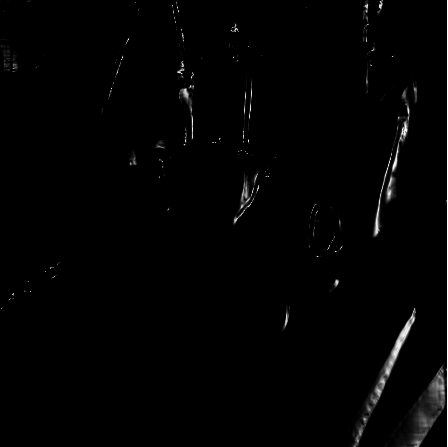

In [28]:
rgb(
    result["highlight"][0],
    resize=(448, 448),
    colormap="gray",
)

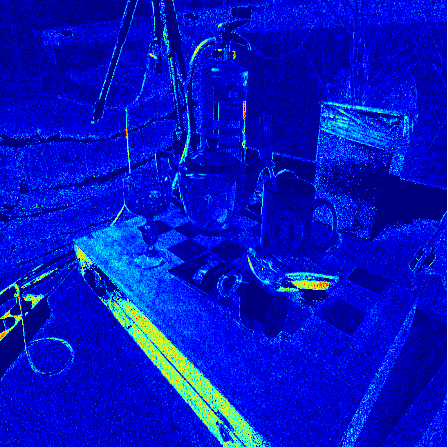

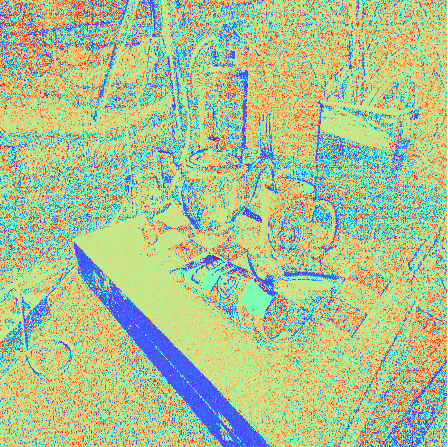

(None,)

In [38]:
# rgb(
#     panelize(
rgb(batch["DoP"],  colormap="jet", resize=(448, 448))
rgb(
    batch["AoP"][0],
    colormap="rainbow",
    resize=(448, 448),
),
#     )
# )

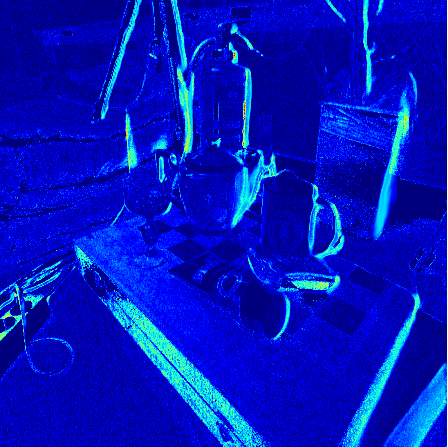

(None,)

In [74]:
# rgb(
#     panelize(
# rgb(image,  resize=(448, 448
rgb(
    0.5*result["H_dop"][0].cpu()+batch["DoP"][0].cpu(),
    colormap="jet",
    resize=(448, 448),
),
#     )
# )

In [46]:
torch.cross(result["view_dir"], result["light_dir"], dim=1).shape

torch.Size([1, 3, 448, 448])

In [58]:
k.shape

torch.Size([3, 448, 448])

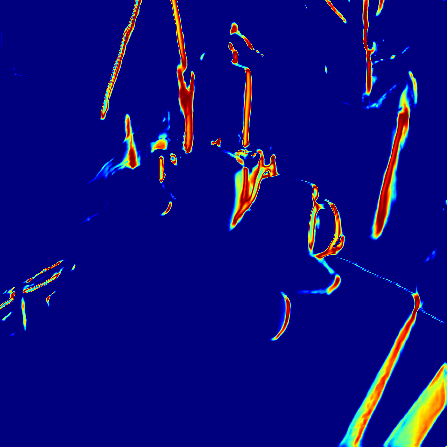

In [64]:
# rgb(result["view_dir"][0], resize=(448, 448))
# rgb(result["light_dir"][0], resize=(448, 448))
k = torch.cross(result["view_dir"], result["light_dir"], dim=1).mean(dim=1)
# ex = k[:, 0:1]  # x-component [B,1,H,W]
# ey = k[:, 1:2]  # y-component [B,1,H,W]
# phi = torch.atan2(ey, ex)  # [-pi,pi] [B,1,H,W]
rgb(result["H_dop"], colormap="jet", resize=(448, 448))

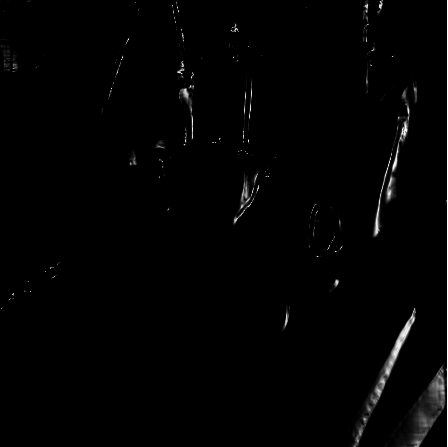

In [65]:
rgb(result["highlight"], colormap="gray", resize=(448, 448))

In [6]:
from polar_highlighter import PolarHighlighter

ph = PolarHighlighter(height=image.shape[2], width=image.shape[3]).cuda()
ph.enable_timing_mode(True)


Using a slow image processor as `use_fast` is unset and a slow processor was saved with this model. `use_fast=True` will be the default behavior in v4.52, even if the model was saved with a slow processor. This will result in minor differences in outputs. You'll still be able to use a slow processor with `use_fast=False`.


Some weights of DPTForDepthEstimation were not initialized from the model checkpoint at Intel/dpt-large and are newly initialized: ['neck.fusion_stage.layers.0.residual_layer1.convolution1.bias', 'neck.fusion_stage.layers.0.residual_layer1.convolution1.weight', 'neck.fusion_stage.layers.0.residual_layer1.convolution2.bias', 'neck.fusion_stage.layers.0.residual_layer1.convolution2.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [7]:
import rerun as rr

rr.init("polar_highlighter")
rr.serve_web(web_port=0, grpc_port=torch.randint(10000, 65535, (1,)).item())
rr.log("/", rr.ViewCoordinates.RIGHT_HAND_Y_DOWN)

highlight


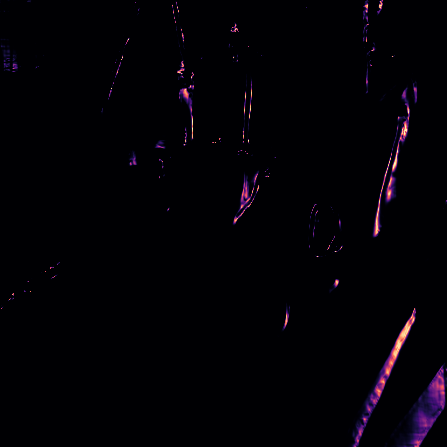

rgb_highlighted


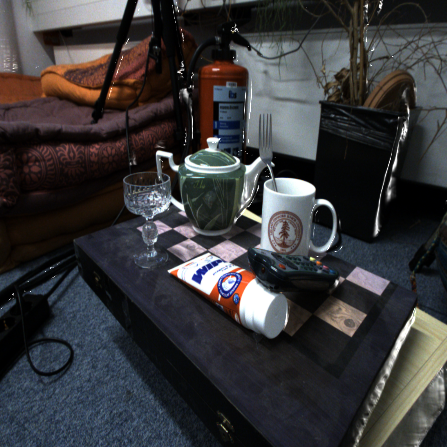

stokes_highlight


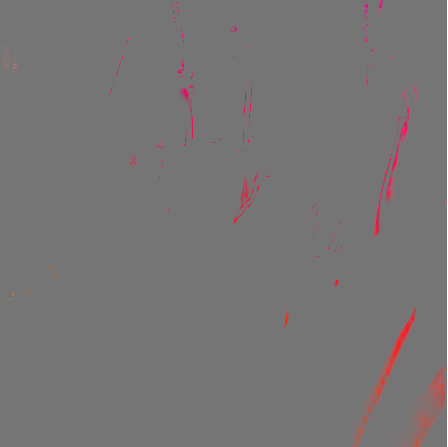

stokes_highlighted


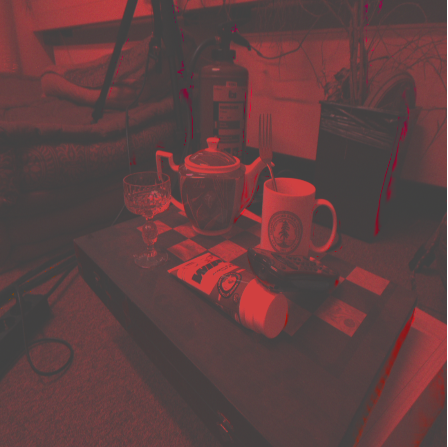

depth


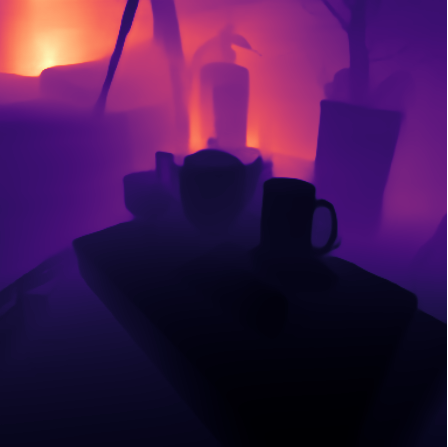

normals


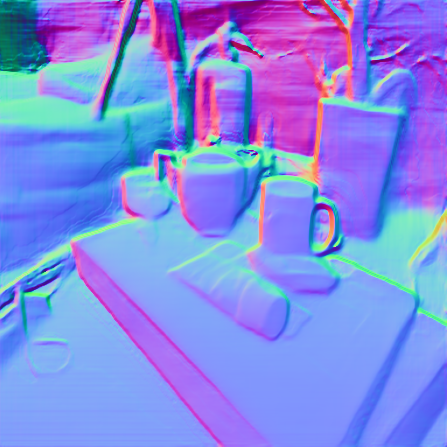

H_dop


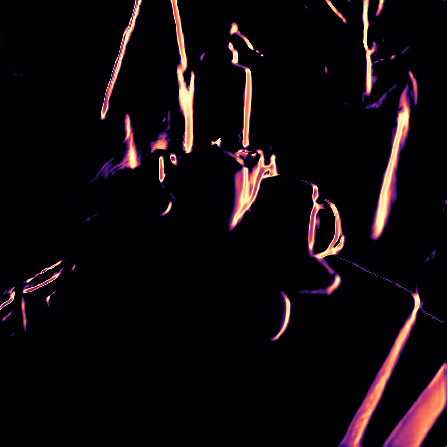

H_aop


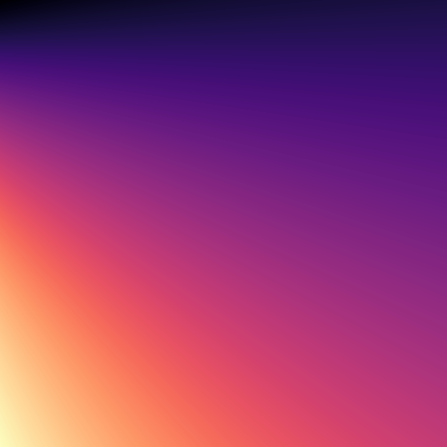

light_dir


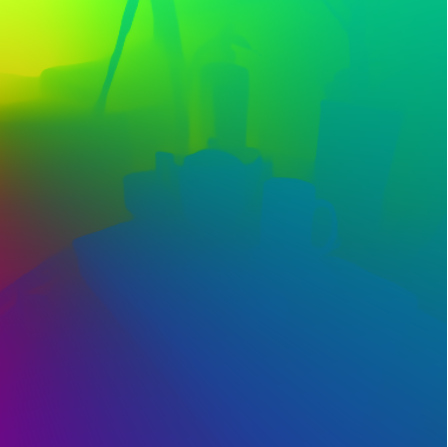

view_dir


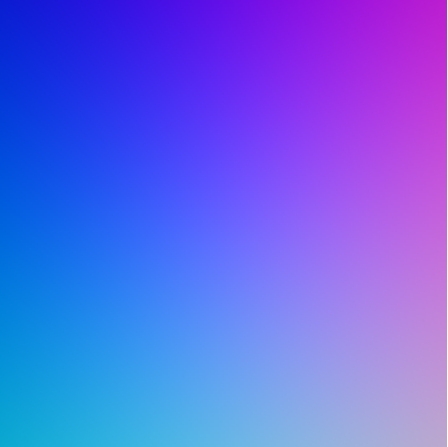

In [41]:
for n, x in result.items():
    if x.ndim == 4 and n != "pcloud":
        print(n)
        rgb(x[0], resize=(448, 448))

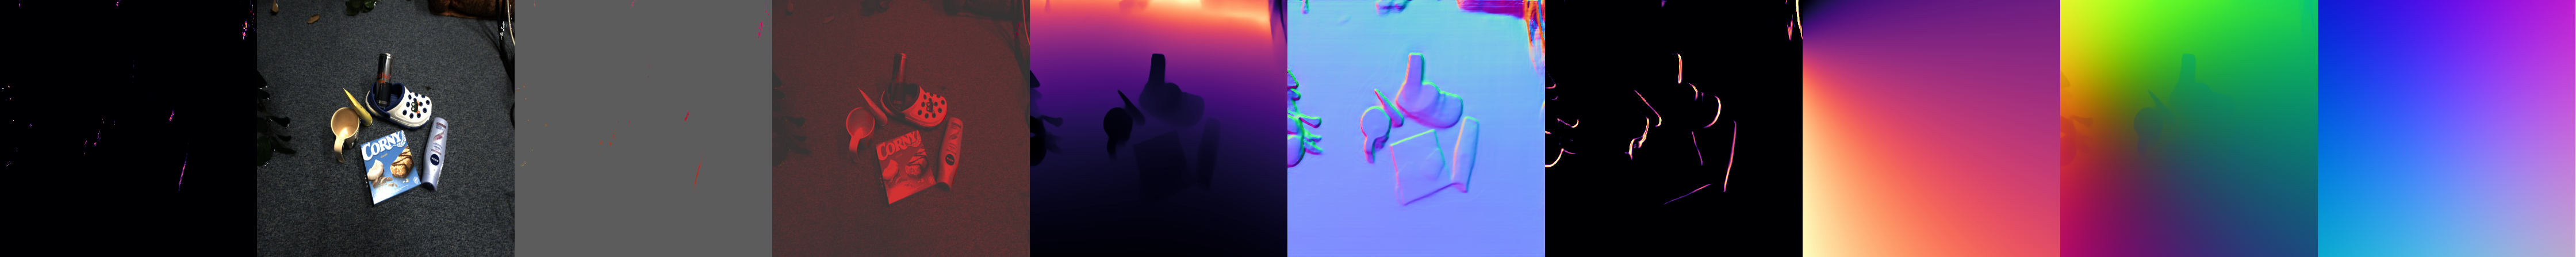

In [15]:
result = ph(image, pol, intrinsic_res)
# ph.print_timing_stats()
rgb(
    panelize(
        *[
            rgb(x[0], as_tensor=True, resize=(448, 448), title=n)
            for n, x in result.items()
            if x.ndim == 4 and n != "pcloud" 
        ],
    )
)


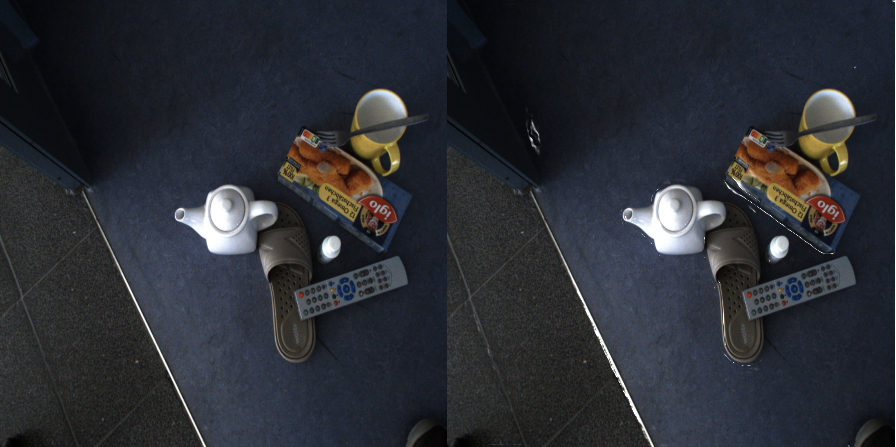

In [22]:
rgb(
    panelize(
        rgb(image, as_tensor=True, resize=(448, 448), title="img"),
        rgb(
            result["rgb_highlighted"][0],
            as_tensor=True,
            resize=(448, 448),
            title="highlight",
        ),
    )
)

In [18]:
result["normals"].shape

torch.Size([1, 3, 448, 448])

In [75]:
import rerun as rr

rr.init("polar_highlighter")
rr.serve_web(web_port=0, grpc_port=torch.randint(10000, 65535, (1,)).item())
rr.log("/", rr.ViewCoordinates.RIGHT_HAND_Y_DOWN)

In [ ]:
rr.log(
    "/cam",
    rr.Pinhole(
        image_from_camera=intrinsic_res[0].cpu().numpy(),  # (3, 3)
        resolution=(
            448,
            448,
        ),  # (2,)
        camera_xyz=rr.components.ViewCoordinates.RDF,  # Default: X=Right, Y=Down, Z=Forward
    ),
)
# for i in range(400):
rr.log(
    "/light",
    rr.Points3D(
        positions=result["light_pos"].cpu().numpy().reshape(1, 3),
        colors=torch.tensor([1.0, 1.0, 1.0]).cpu().numpy().reshape(1, 3),
        radii=5,
    ),
)

rr.log(
    "/pcloud",
    rr.Points3D(
        positions=result["pcloud"].view(1, 3, -1)[0].permute(1, 0).cpu().numpy(),
        colors=image.view(1, 3, -1)[0].permute(1, 0).cpu().numpy(),
        # colors=result["pcloud_computed"][:,2].permute(1, 0).cpu().numpy()/result["pcloud_computed"][:,2].permute(1, 0).max().cpu().numpy(),
    ),
)
# Log normals as 3D arrows at each point in the point cloud
CLOUD_DOWNS = 50
ARROW_LENGTH = 10
ARROW_RADIUS = 0.5
rr.log(
    "/normals",
    rr.Arrows3D(
        origins=result["pcloud"][:,:,::10,::10].reshape(1, 3, -1)[0].permute(1, 0).cpu().numpy(),  # [N, 3] positions
        vectors=-result["normals"][:,:,::10,::10].reshape(1, 3, -1)[0].permute(1, 0).cpu().numpy()*ARROW_LENGTH,  # [N, 3] normal directions
        colors=torch.nn.functional.normalize(result["normals"][:,:,::10,::10].reshape(1, 3, -1)[0].permute(1, 0), dim=1).cpu().numpy() * 0.5 + 0.5,  # HSV-like coloring based on normal directions
        radii=ARROW_RADIUS/2,  # Arrow thickness
    ),
)
rr.log(
    "/normals",
    rr.Arrows3D(
        origins=result["pcloud"][:,:,::CLOUD_DOWNS,::CLOUD_DOWNS].reshape(1, 3, -1)[0].permute(1, 0).cpu().numpy(),  # [N, 3] positions
        vectors=-result["normals"][:,:,::CLOUD_DOWNS,::CLOUD_DOWNS].reshape(1, 3, -1)[0].permute(1, 0).cpu().numpy()*ARROW_LENGTH,  # [N, 3] normal directions
        colors=torch.nn.functional.normalize(result["normals"][:,:,::CLOUD_DOWNS,::CLOUD_DOWNS].reshape(1, 3, -1)[0].permute(1, 0), dim=1).cpu().numpy() * 0.5 + 0.5,  # HSV-like coloring based on normal directions
        radii=ARROW_RADIUS,  # Arrow thickness
    ),
)
rr.log(
    "/light_dir",
    rr.Arrows3D(
        origins=result["pcloud"][:,:,::CLOUD_DOWNS,::CLOUD_DOWNS].reshape(1, 3, -1)[0].permute(1, 0).cpu().numpy(),  # [N, 3] positions
        vectors=result["light_dir"][:,:,::CLOUD_DOWNS,::CLOUD_DOWNS].reshape(1, 3, -1)[0].permute(1, 0).cpu().numpy()*ARROW_LENGTH,  # [N, 3] normal directions
        colors=torch.ones_like(result["light_dir"][:,:,::CLOUD_DOWNS,::CLOUD_DOWNS].reshape(1, 3, -1)[0].permute(1, 0)).cpu().numpy(),
        radii=ARROW_RADIUS,  # Arrow thickness
    ),
)
rr.log(
    "/view_dir",
    rr.Arrows3D(
        origins=result["pcloud"][:,:,::CLOUD_DOWNS,::CLOUD_DOWNS].reshape(1, 3, -1)[0].permute(1, 0).cpu().numpy(),  # [N, 3] positions
        vectors=-result["view_dir"][:,:,::CLOUD_DOWNS,::CLOUD_DOWNS].reshape(1, 3, -1)[0].permute(1, 0).cpu().numpy()*ARROW_LENGTH,  # [N, 3] normal directions
        colors=torch.tensor([1.0, 0.0, 0.0]).expand_as(result["view_dir"][:,:,::CLOUD_DOWNS,::CLOUD_DOWNS].reshape(1, 3, -1)[0].permute(1, 0)).cpu().numpy(),
        radii=ARROW_RADIUS,  # Arrow thickness
    ),
)


In [32]:
result["pcloud"].reshape(1, 3, -1)[0].permute(1, 0).shape

torch.Size([200704, 3])

In [ ]:
rgb(
    panelize(
        rgb(
            batch["rgb"][0],
            as_tensor=True,
            resize=(892, 1140),
            colormap="gray",
        ),
        panelize(
            panelize(
                rgb(
                    0.2 * batch["specular"][0] + 0.8 * batch["diffuse"][0],
                    as_tensor=True,
                    resize=(448, 448),
                ),
                rgb(
                    0.4 * batch["specular"][0] + 0.6 * batch["diffuse"][0],
                    as_tensor=True,
                    resize=(448, 448),
                ),
                rgb(
                    0.6 * batch["specular"][0] + 0.4 * batch["diffuse"][0],
                    as_tensor=True,
                    resize=(448, 448),
                ),
                rgb(
                    0.8 * batch["specular"][0] + 0.2 * batch["diffuse"][0],
                    as_tensor=True,
                    resize=(448, 448),
                ),
            ),
            panelize(
                rgb(
                    0.8 * batch["specular"][0] + 0.2 * batch["diffuse"][0],
                    as_tensor=True,
                    resize=(448, 448),
                ),
                rgb(
                    0.6 * batch["specular"][0] + 0.4 * batch["diffuse"][0],
                    as_tensor=True,
                    resize=(448, 448),
                ),
                rgb(
                    0.4 * batch["specular"][0] + 0.6 * batch["diffuse"][0],
                    as_tensor=True,
                    resize=(448, 448),
                ),
                rgb(
                    0.2 * batch["specular"][0] + 0.8 * batch["diffuse"][0],
                    as_tensor=True,
                    resize=(448, 448),
                ),
            ),
            mode="vertical",
        ),
        resize_to_match=False,
    )
)